# Calcium Imaging Pipeline
**Modes:**
- `SINGLE_FILE = True` → load only the first `.ome.tif` chunk (laptop / dev)
- `SINGLE_FILE = False` → full recording (workstation)
- `USE_GPU = True` → CuPy acceleration — `pip install cupy-cuda12x` (adjust cuda version to match yours)

In [6]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
EXPERIMENT_DIR  = r"Z:\ephacoffice\DColameo\Ca_Anand_AllData\07_11_25_Min6WT_Binning2_2_250ms_Exp3"

SINGLE_FILE     = True   # True = first chunk only (fast); False = full recording
USE_GPU         = False  # True = CuPy (needs: pip install cupy-cuda12x)

SOURCE_FPS      = 4      # acquisition FPS
TARGET_FPS      = 1      # output FPS (frames averaged per output frame = SOURCE_FPS/TARGET_FPS)
SPATIAL_BINNING = 2      # extra spatial binning (1 = none; 2 = halve each dimension)

# Segmentation — tune after seeing Step 6 output
GAUSS_SIGMA     = 2.0    # smoothing sigma (pixels, post-binning)
MIN_CELL_AREA   = 20     # min ROI area in pixels
MAX_CELL_AREA   = 500    # max ROI area in pixels
# ─────────────────────────────────────────────────────────────────────────────

In [7]:
import re, json
from pathlib import Path

import numpy as np
import tifffile
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import filters, morphology, measure, segmentation, feature
from skimage.color import label2rgb

# ── GPU / CPU backend ────────────────────────────────────────────────────────
if USE_GPU:
    try:
        import cupy as xp
        xp.array([1])  # trigger device init
        props = xp.cuda.runtime.getDeviceProperties(0)
        mem_gb = xp.cuda.Device(0).mem_info[1] / 1e9
        print(f"GPU: {props['name'].decode()}  ({mem_gb:.1f} GB VRAM)  — CuPy active")
    except Exception as e:
        print(f"CuPy unavailable ({e}) — falling back to CPU")
        import numpy as xp
        USE_GPU = False
else:
    xp = np
    print("CPU mode (numpy)")

def to_cpu(a):
    return xp.asnumpy(a) if USE_GPU else np.asarray(a)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

CPU mode (numpy)


## Step 1 — Discover files

In [8]:
exp_dir = Path(EXPERIMENT_DIR)

def _num_key(p):
    return tuple(int(n) for n in re.findall(r'\d+', p.name))

segment_dirs = sorted(
    [d for d in exp_dir.iterdir() if d.is_dir() and not d.name.startswith('40')],
    key=_num_key
)

all_tifs = []
for seg in segment_dirs:
    all_tifs.extend(sorted(seg.glob('*.ome.tif'), key=_num_key))

print(f"Experiment : {exp_dir.name}")
print(f"Segments   : {len(segment_dirs)}")
print(f"Total TIFs : {len(all_tifs)}")
for t in all_tifs:
    print(f"  {t.parent.name}/{t.name}")

tifs_to_load = all_tifs[:1] if SINGLE_FILE else all_tifs
print(f"\n{'[SINGLE FILE]' if SINGLE_FILE else '[FULL RECORDING]'} Loading {len(tifs_to_load)} file(s)")

Experiment : 07_11_25_Min6WT_Binning2_2_250ms_Exp3
Segments   : 4
Total TIFs : 9
  1_1/1_1_MMStack_Default.ome.tif
  1_2/1_2_MMStack_Default.ome.tif
  1_2/1_2_MMStack_Default_1.ome.tif
  1_3/1_3_MMStack_Default.ome.tif
  1_3/1_3_MMStack_Default_1.ome.tif
  1_3/1_3_MMStack_Default_2.ome.tif
  1_4/1_4_MMStack_Default.ome.tif
  1_4/1_4_MMStack_Default_1.ome.tif
  1_4/1_4_MMStack_Default_2.ome.tif

[SINGLE FILE] Loading 1 file(s)


## Step 2 — Inspect first file

In [9]:
with tifffile.TiffFile(tifs_to_load[0]) as tf:
    s = tf.asarray()
    print(f"File   : {tifs_to_load[0].name}")
    print(f"Shape  : {s.shape}   (frames × height × width)")
    print(f"Dtype  : {s.dtype}")
    print(f"Range  : {s.min()} – {s.max()}")
    print(f"Memory : {s.nbytes / 1e6:.0f} MB per file")
    try:
        meta = json.loads(tf.pages[0].description)
        iv = meta.get('Interval_ms') or meta.get('interval_ms')
        if iv:
            print(f"FPS (metadata): {1000/float(iv):.2f}")
    except Exception:
        pass

File   : 1_1_MMStack_Default.ome.tif
Shape  : (1200, 1100, 1600)   (frames × height × width)
Dtype  : uint16
Range  : 78 – 229
Memory : 4224 MB per file


## Step 3 — Load data

In [10]:
print(f"Loading {len(tifs_to_load)} file(s) ...")
chunks = []
for p in tifs_to_load:
    a = tifffile.imread(str(p))
    if a.ndim == 2:
        a = a[np.newaxis]
    chunks.append(a)
    print(f"  {p.parent.name}/{p.name}  {a.shape}  {a.nbytes/1e6:.0f} MB")

raw_cpu = np.concatenate(chunks, axis=0)   # always assemble on CPU
del chunks
print(f"\nLoaded  : {raw_cpu.shape}  dtype={raw_cpu.dtype}")
print(f"Duration: {raw_cpu.shape[0] / SOURCE_FPS:.1f} s  ({raw_cpu.nbytes/1e9:.2f} GB)")

# Move to GPU if enabled
raw = xp.asarray(raw_cpu.astype(np.float32))
del raw_cpu
if USE_GPU:
    print(f"Transferred to GPU ({raw.nbytes/1e6:.0f} MB VRAM used)")

Loading 1 file(s) ...
  1_1/1_1_MMStack_Default.ome.tif  (1200, 1100, 1600)  4224 MB

Loaded  : (1200, 1100, 1600)  dtype=uint16
Duration: 300.0 s  (4.22 GB)


## Step 4 — Temporal downsampling
Average every `SOURCE_FPS / TARGET_FPS` frames → 1 FPS output

In [11]:
ratio  = SOURCE_FPS // TARGET_FPS
T, H, W = raw.shape
T_trim  = (T // ratio) * ratio

# Reshape and mean — runs on GPU if xp=cupy
downsampled = raw[:T_trim].reshape(T_trim // ratio, ratio, H, W).mean(axis=1)

print(f"Temporal downsampling {ratio}x : {T} → {downsampled.shape[0]} frames  ({downsampled.shape[0]} s)")

Temporal downsampling 4x : 1200 → 300 frames  (300 s)


## Step 5 — Spatial binning

In [12]:
if SPATIAL_BINNING > 1:
    b = SPATIAL_BINNING
    T2, H2, W2 = downsampled.shape
    Hb, Wb = H2 // b, W2 // b
    mov = downsampled[:, :Hb*b, :Wb*b].reshape(T2, Hb, b, Wb, b).mean(axis=(2, 4))
    print(f"Spatial binning {b}x : ({H2}, {W2}) → ({Hb}, {Wb})")
else:
    mov = downsampled
    print("No spatial binning.")

print(f"Movie : {mov.shape}  ({mov.nbytes/1e6:.0f} MB)")

Spatial binning 2x : (1100, 1600) → (550, 800)
Movie : (300, 550, 800)  (528 MB)


## Step 6 — Summary projections
**Check here**: Std image should show bright blobs where cells are. If it looks flat, try lowering `SPATIAL_BINNING` to 1.

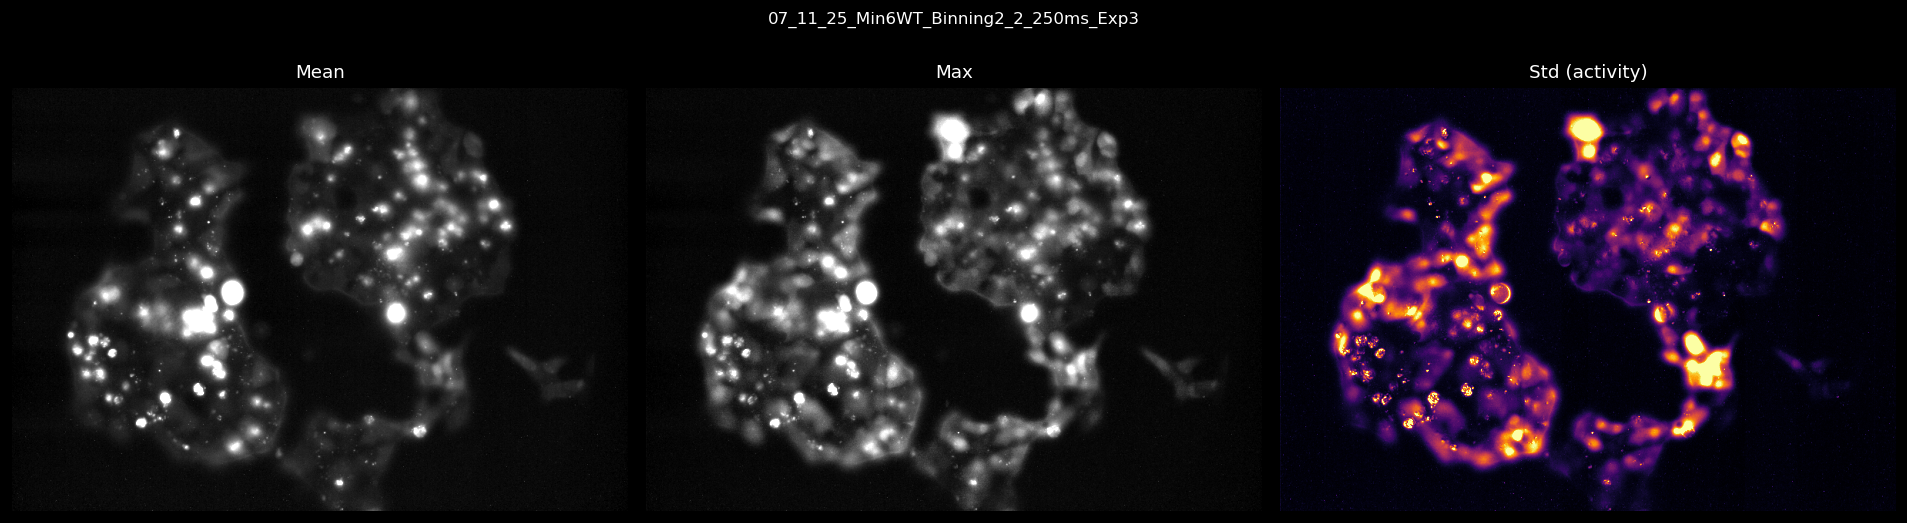

In [13]:
# Computed on GPU if enabled, then pulled to CPU for plotting
mean_img = to_cpu(mov.mean(axis=0)).astype(np.float32)
max_img  = to_cpu(mov.max(axis=0)).astype(np.float32)
std_img  = to_cpu(mov.std(axis=0)).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, img, title, cmap in zip(
    axes,
    [mean_img, max_img, std_img],
    ['Mean', 'Max', 'Std (activity)'],
    ['gray', 'gray', 'inferno']
):
    p1, p99 = np.percentile(img, [1, 99])
    ax.imshow(img, cmap=cmap, vmin=p1, vmax=p99)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle(exp_dir.name, fontsize=10)
plt.tight_layout()
plt.show()

## Step 7 — Cell segmentation  (CPU — only on summary image)
Tune `GAUSS_SIGMA`, `MIN_CELL_AREA`, `MAX_CELL_AREA` at the top and re-run this section.

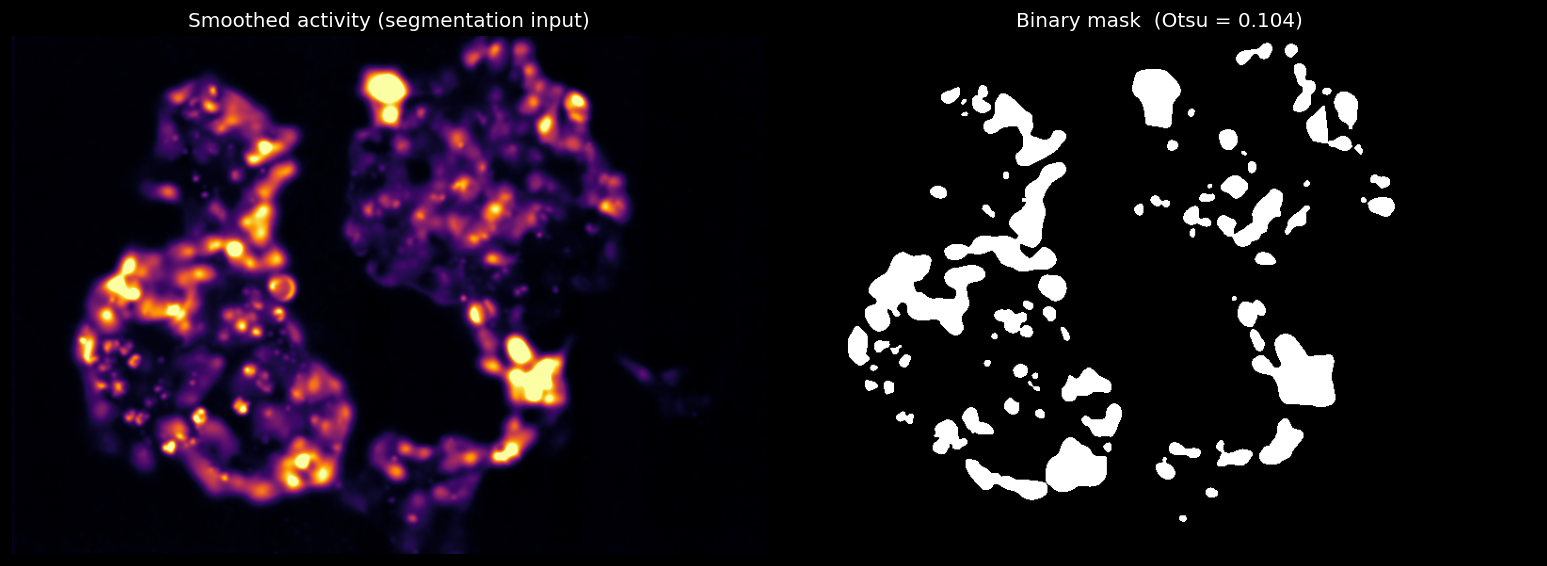

In [14]:
# 7a — smooth + normalise
seg_img = filters.gaussian(std_img, sigma=GAUSS_SIGMA)
seg_img = (seg_img - seg_img.min()) / (seg_img.max() - seg_img.min() + 1e-9)

# 7b — Otsu threshold
thresh = filters.threshold_otsu(seg_img)
binary = seg_img > thresh
binary = morphology.remove_small_objects(binary, min_size=MIN_CELL_AREA)
binary = ndimage.binary_fill_holes(binary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
p1, p99 = np.percentile(seg_img, [1, 99])
axes[0].imshow(seg_img, cmap='inferno', vmin=p1, vmax=p99)
axes[0].set_title('Smoothed activity (segmentation input)')
axes[0].axis('off')
axes[1].imshow(binary, cmap='gray')
axes[1].set_title(f'Binary mask  (Otsu = {thresh:.3f})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

ROIs : 84


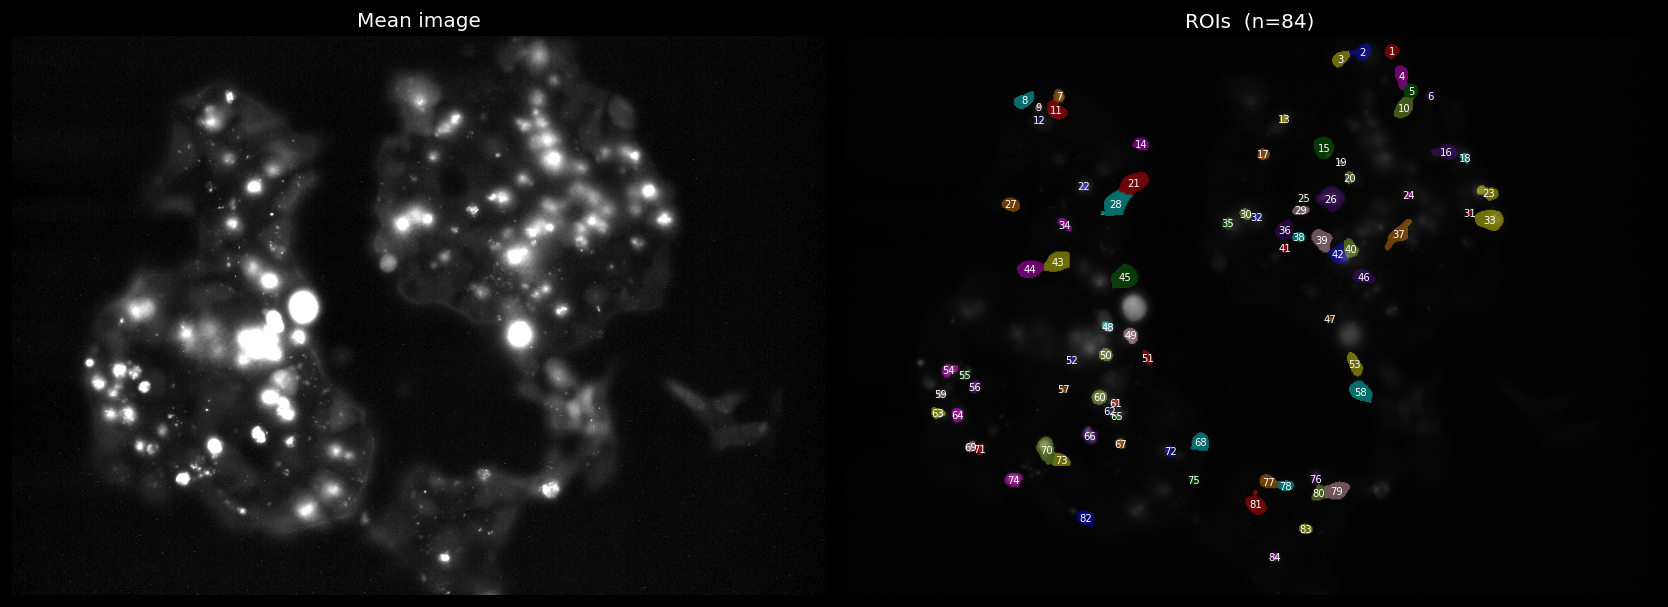

In [16]:
# 7c — watershed to separate touching cells
distance  = ndimage.distance_transform_edt(binary)
local_max = feature.peak_local_max(distance, min_distance=int(GAUSS_SIGMA * 3), labels=binary)
markers   = np.zeros_like(binary, dtype=int)
markers[tuple(local_max.T)] = 1
markers   = measure.label(markers)
labels    = segmentation.watershed(-distance, markers, mask=binary)

# 7d — area filter, re-index
props      = measure.regionprops(labels)
valid      = [p.label for p in props if MIN_CELL_AREA <= p.area <= MAX_CELL_AREA]
roi_mask   = np.zeros_like(labels)
for new_id, old in enumerate(valid, 1):
    roi_mask[labels == old] = new_id
n_cells = len(valid)
print(f"ROIs : {n_cells}")

# 7e — overlay
mean_norm = (mean_img - mean_img.min()) / (mean_img.max() - mean_img.min() + 1e-9)
overlay = label2rgb(roi_mask, image=mean_norm, bg_label=0, alpha=0.4)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
p1, p99 = np.percentile(mean_img, [1, 99])
axes[0].imshow(mean_img, cmap='gray', vmin=p1, vmax=p99)
axes[0].set_title('Mean image')
axes[0].axis('off')
axes[1].imshow(overlay)
axes[1].set_title(f'ROIs  (n={n_cells})')
axes[1].axis('off')
for rp in measure.regionprops(roi_mask):
    y, x = rp.centroid
    axes[1].text(x, y, str(rp.label), color='white', fontsize=6, ha='center', va='center')
plt.tight_layout()
plt.show()

## Step 8 — Extract fluorescence traces
Index gather runs on GPU (if enabled) for speed.

F matrix: (84, 300)  (cells × frames)


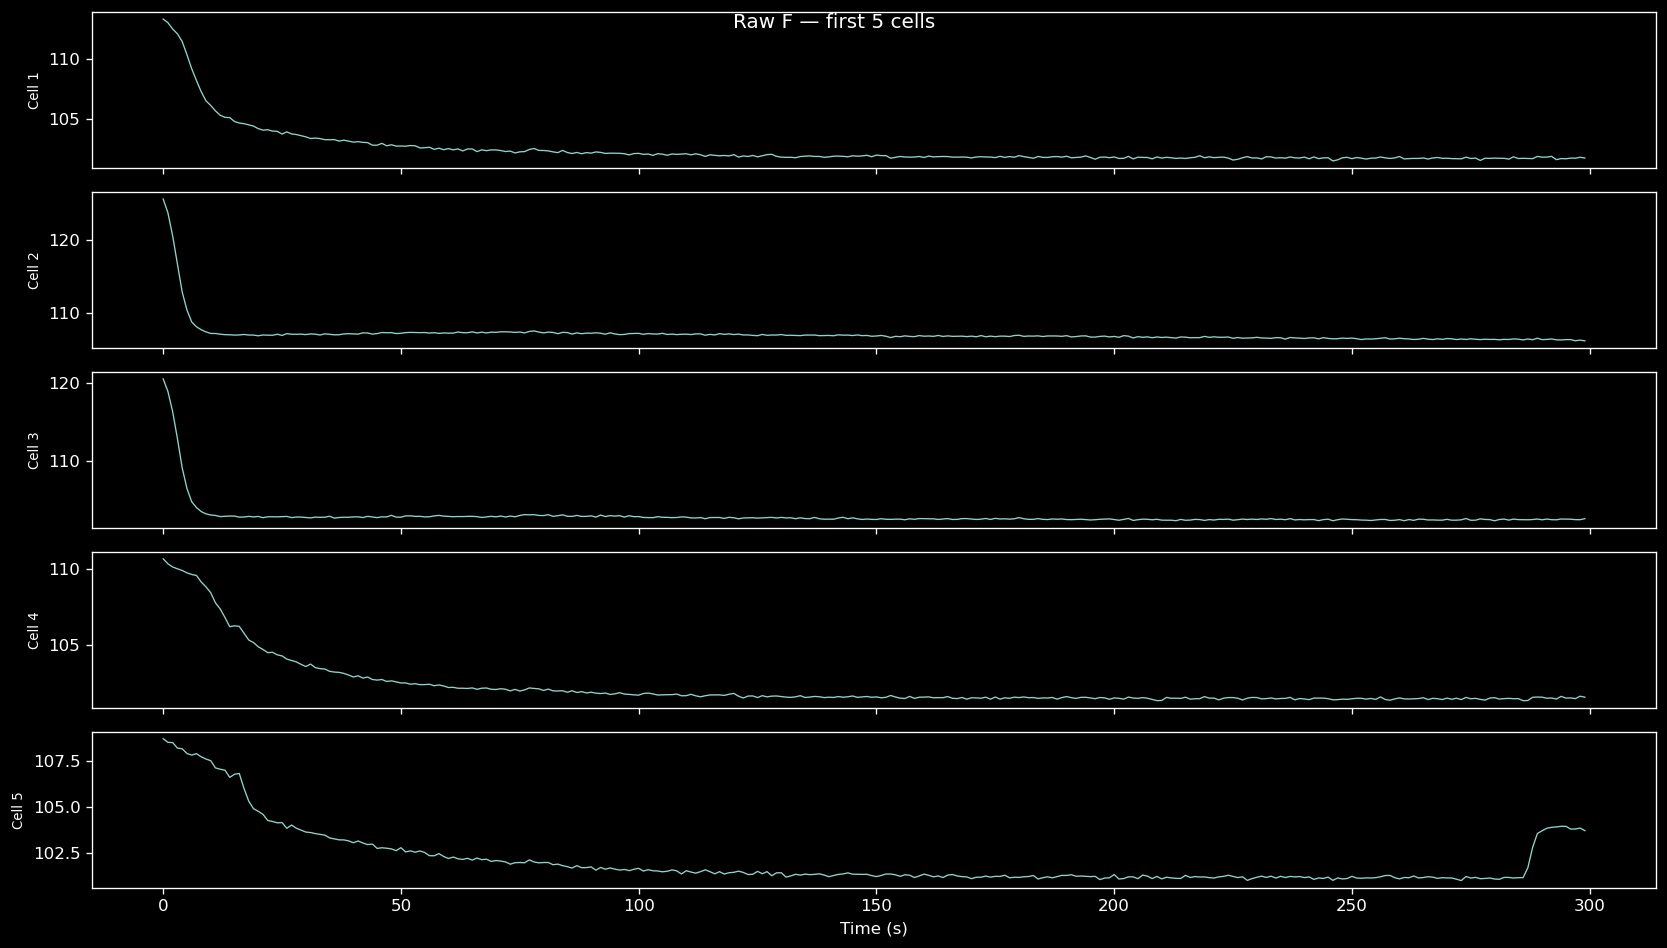

In [17]:
T_final   = mov.shape[0]
time_axis = np.arange(T_final) / TARGET_FPS   # seconds
rprops    = measure.regionprops(roi_mask)

F = np.zeros((n_cells, T_final), dtype=np.float32)
for i, rp in enumerate(rprops):
    ys, xs = np.where(roi_mask == rp.label)
    if USE_GPU:
        ys_g, xs_g = xp.array(ys), xp.array(xs)
        F[i] = to_cpu(mov[:, ys_g, xs_g].mean(axis=1))
    else:
        F[i] = mov[:, ys, xs].mean(axis=1)

print(f"F matrix: {F.shape}  (cells × frames)")

fig, axes = plt.subplots(min(5, n_cells), 1, figsize=(14, 8), sharex=True)
if n_cells == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(time_axis, F[i], lw=0.8)
    ax.set_ylabel(f'Cell {i+1}', fontsize=8)
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Raw F — first 5 cells')
plt.tight_layout()
plt.show()

## Step 9 — dF/F
Rolling 8th-percentile baseline over a 60-s window (robust to transients).  
Tune `baseline_window_s` if you see a drifting baseline.

In [18]:
def compute_dff(F, fps, baseline_window_s=60, pct=8):
    win = max(1, int(baseline_window_s * fps))
    n, T = F.shape
    F0 = np.zeros_like(F)
    for i in range(n):
        for t in range(T):
            lo, hi = max(0, t - win//2), min(T, t + win//2 + 1)
            F0[i, t] = np.percentile(F[i, lo:hi], pct)
    return (F - F0) / (F0 + 1e-6), F0

print("Computing dF/F ...")
dff, F0 = compute_dff(F, TARGET_FPS)
print(f"dF/F: {dff.shape}")

Computing dF/F ...
dF/F: (84, 300)


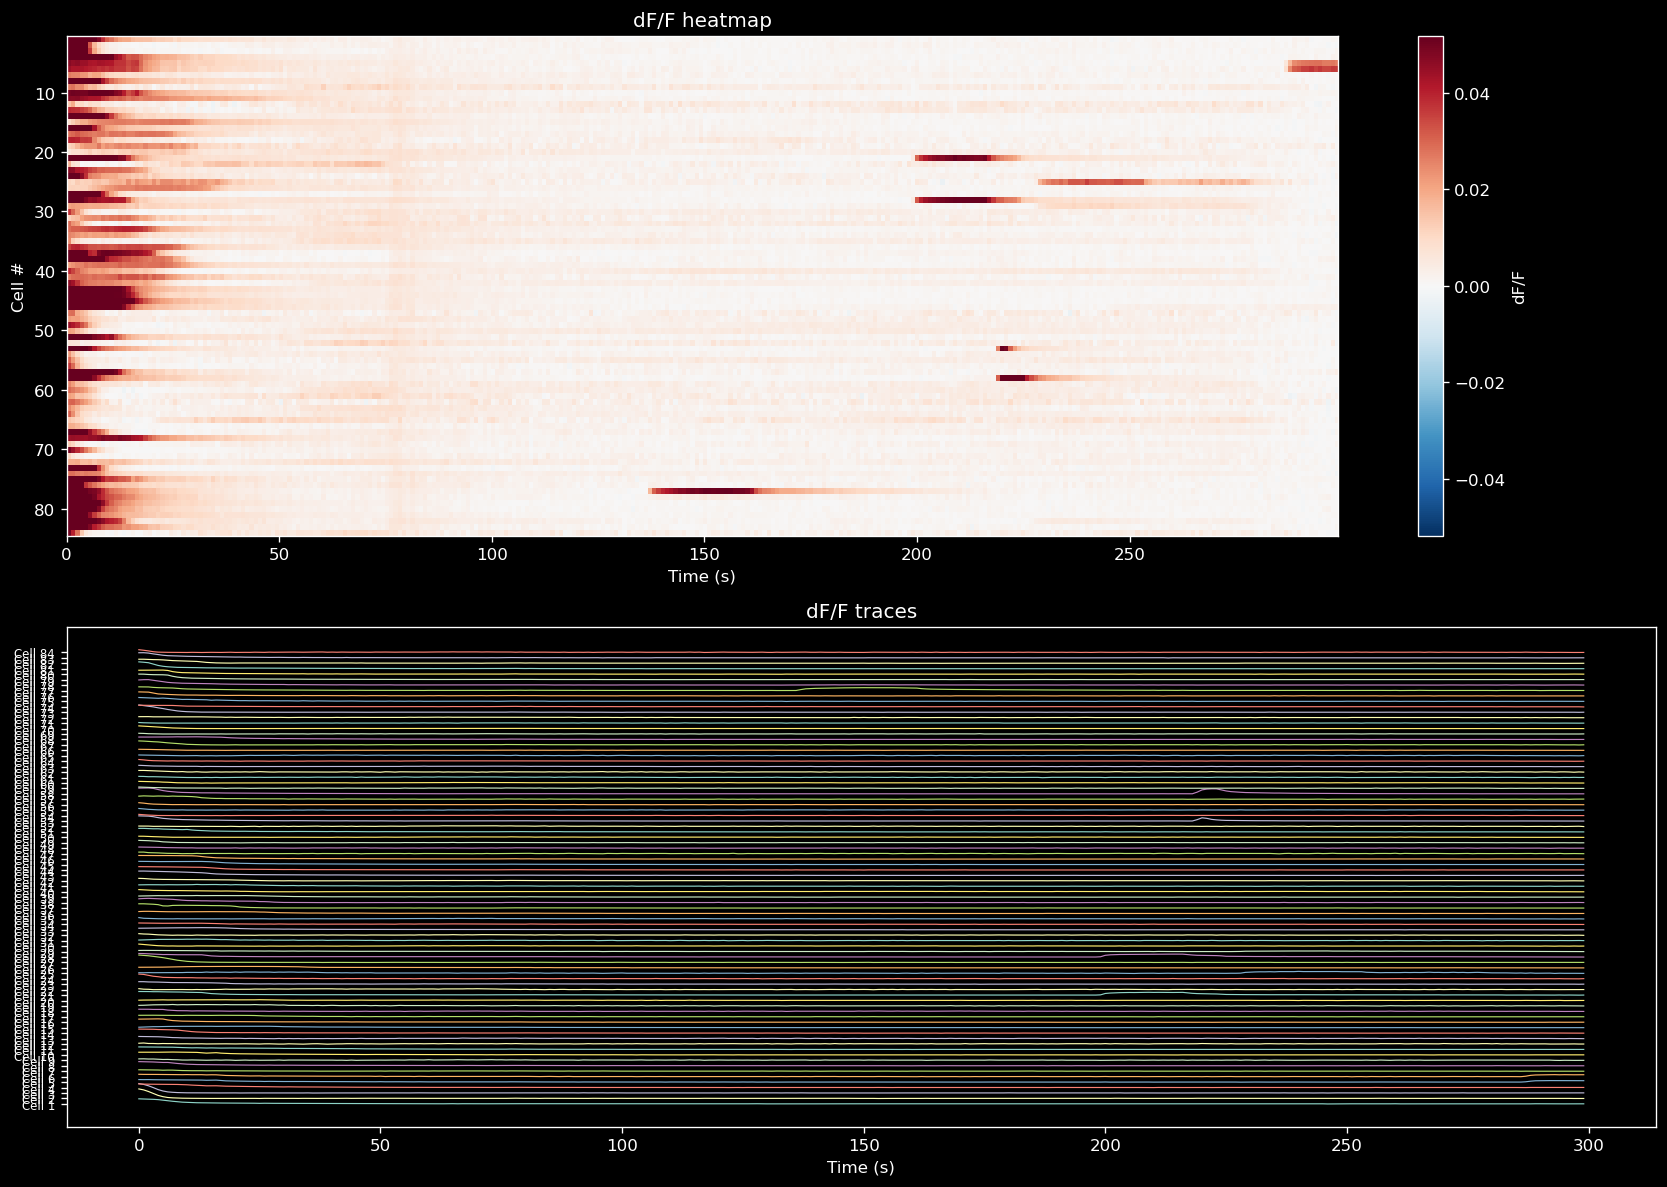

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

vmax = np.percentile(np.abs(dff), 99)
im = axes[0].imshow(dff, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                    extent=[0, time_axis[-1], n_cells + 0.5, 0.5])
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Cell #')
axes[0].set_title('dF/F heatmap')
plt.colorbar(im, ax=axes[0], label='dF/F')

step = max(np.percentile(np.abs(dff), 95) * 3, 0.1)
for i in range(n_cells):
    axes[1].plot(time_axis, dff[i] + i * step, lw=0.7)
axes[1].set_xlabel('Time (s)')
axes[1].set_title('dF/F traces')
axes[1].set_yticks(np.arange(n_cells) * step)
axes[1].set_yticklabels([f'Cell {i+1}' for i in range(n_cells)], fontsize=7)
plt.tight_layout()
plt.show()

## Step 10 — Save

In [ ]:
tag     = '_single' if SINGLE_FILE else ''
out_dir = exp_dir / f'pipeline_output{tag}'
out_dir.mkdir(exist_ok=True)

np.save(out_dir / 'roi_mask.npy',  roi_mask)
np.save(out_dir / 'F_raw.npy',     F)
np.save(out_dir / 'dff.npy',       dff)
np.save(out_dir / 'time_axis.npy', time_axis)
tifffile.imwrite(str(out_dir / 'mean_image.tif'), mean_img)

print(f"Saved → {out_dir}")
for name, arr in [('roi_mask', roi_mask), ('F_raw', F), ('dff', dff), ('time_axis', time_axis)]:
    print(f"  {name}.npy  {arr.shape}")